In [1]:
import gymnasium as gym
import numpy as np
import random

# -------------------------------
# Create the Taxi environment
# -------------------------------
env = gym.make("Taxi-v3")

# -------------------------------
# Initialize Q-table
# -------------------------------
state_space_size = env.observation_space.n   # 500 states
action_space_size = env.action_space.n       # 6 actions

Q = np.zeros((state_space_size, action_space_size))

# -------------------------------
# Hyperparameters
# -------------------------------
alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor
epsilon = 1.0        # Exploration rate
epsilon_min = 0.01
epsilon_decay = 0.995

num_episodes = 2000
max_steps_per_episode = 100

# -------------------------------
# Training phase
# -------------------------------
episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps_per_episode):

        # ε-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()   # Explore
        else:
            action = np.argmax(Q[state])         # Exploit

        next_state, reward, done, truncated, _ = env.step(action)

        # Q-learning update rule
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    # Decay epsilon : Explore more at the beginning, exploit more later
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)

    # Print progress occasionally
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode+1}, Average Reward (last 100): {np.mean(episode_rewards[-100:]):.2f}")

env.close()

print("\nTraining finished!")

# -------------------------------
# Testing the trained agent
# -------------------------------
env = gym.make("Taxi-v3", render_mode="human")

state, _ = env.reset()
done = False
total_reward = 0

print("\nTesting trained agent...\n")

while not done:
    action = np.argmax(Q[state])
    state, reward, done, truncated, _ = env.step(action)
    total_reward += reward

env.close()
print("Total reward during test episode:", total_reward)


Episode 500, Average Reward (last 100): -97.85
Episode 1000, Average Reward (last 100): -29.79
Episode 1500, Average Reward (last 100): 0.54
Episode 2000, Average Reward (last 100): 5.45

Training finished!

Testing trained agent...

Total reward during test episode: 7


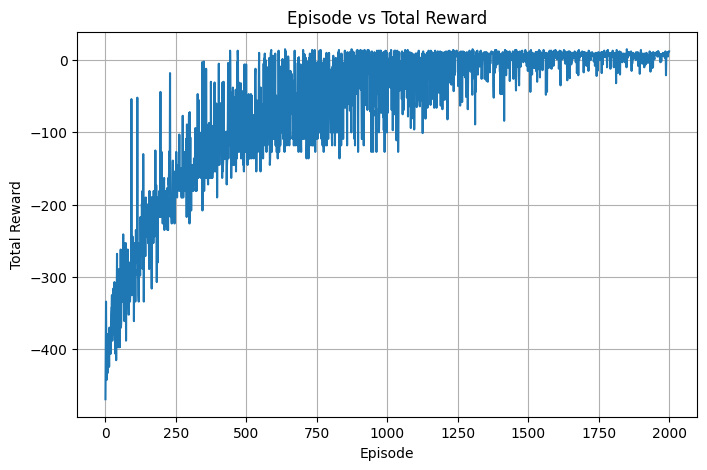

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode vs Total Reward")
plt.grid()
plt.show()
